# Sodium/Calcium relationship plot

Copying code from Jacob here

In [6]:
# %% Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [7]:
# set filepaths
path_to_context = '../../data/broader_context/chem/'
path_to_data = '../../data/sampling/master/'

# ensure plot folder exists
path_to_figures = '../../../figures/discussion/'
os.makedirs(path_to_figures, exist_ok=True)

In [11]:
# load ALHIC1901 data
alhic1901 = pd.read_csv(path_to_data+'ic_icpms_master.csv')


# keep only the Na and Ca columns
alhic1901_ICPMS = alhic1901[['Ca','Na']]
alhic1901_IC = alhic1901[['Ca2+','Na+']]

# drop nans
alhic1901_ICPMS = alhic1901_ICPMS.dropna()
alhic1901_IC = alhic1901_IC.dropna()

In [12]:
# Load EPICA data

# ions.txt appears to be whitespace or tab delimited; using a flexible separator.
epica = pd.read_csv(
    path_to_context+"ions.txt",
    sep=r"\s+",
    engine="python"
)

# Build masks for EPICA glacial and interglacial intervals
glacialI = (
    ((epica["Age_kabp"] >= 20) & (epica["Age_kabp"] <= 80)) |
    ((epica["Age_kabp"] >= 140) & (epica["Age_kabp"] <= 190))
)
interI = (
    ((epica["Age_kabp"] > 1) & (epica["Age_kabp"] <= 15)) |
    ((epica["Age_kabp"] > 115) & (epica["Age_kabp"] <= 130))
)

epicaInter = epica.loc[interI].copy()
epicaGlacial = epica.loc[glacialI].copy()

# keep only Na and Ca columns
epicaInter = epicaInter[['Ca','Na']]
epicaGlacial = epicaGlacial[['Ca','Na']]

# drop nans
epicaInter = epicaInter.dropna()
epicaGlacial = epicaGlacial.dropna()

In [13]:
# load ALHIC1903 data
alhic1903 = pd.read_csv(path_to_context+"ALHIC1903_MajorIons.csv")

# drop nans
ca_col_1903 = 'Ca2+ (µg/L)'
na_col_1903 = 'Na+ (µg/L)'
alhic1903 = alhic1903.dropna(subset=[ca_col_1903,na_col_1903,'Age (ka)']) 

# Split glacial vs interglacial for AH1903
ah1903Glacial = alhic1903[alhic1903["Age (ka)"] >= 134.5].copy()
ah1903Inter = alhic1903[alhic1903["Age (ka)"] <= 134.5].copy()



In [14]:
colors = ["white", "darkblue"] 
custom_blues_cmap = LinearSegmentedColormap.from_list("white_to_darkblue", colors)
cmap_glac = custom_blues_cmap

colors = ["white", "darkred"] 
custom_reds_cmap = LinearSegmentedColormap.from_list("white_to_darkred", colors)
cmap_inter = custom_reds_cmap 


Text(0, 0.5, '')

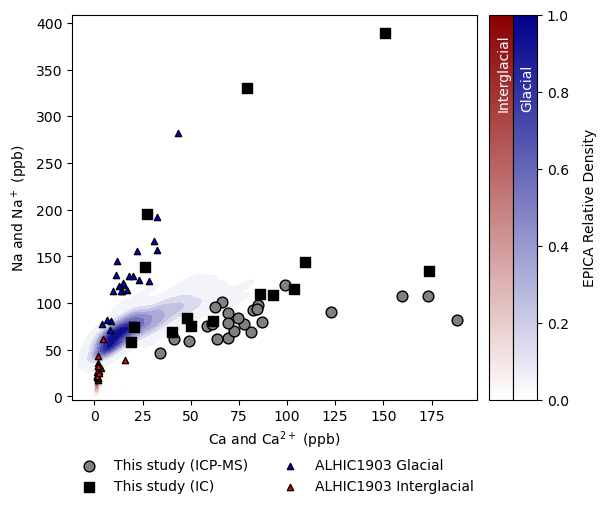

In [24]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(6,5))


# use seaborn kdeplot to plot density contours for EPICA interglacial and glacial
sns.kdeplot(
    data=epicaInter,
    x='Ca',
    y='Na',
    fill=True,
    levels=10,
    cmap=cmap_inter,
    alpha=1,
    thresh=0.01,
    ax=ax,
)
sns.kdeplot(
    data=epicaGlacial,
    x='Ca',
    y='Na',
    fill=True,
    levels=10,
    cmap=cmap_glac,
    alpha=1,
    thresh=0.01,
    ax=ax,
)

# Plot ALHIC1901 points (ICP-MS and IC) and ALHIC1903 if available — filter positive values for log axes
if 'Ca' in alhic1901_ICPMS.columns and 'Na' in alhic1901_ICPMS.columns:
    df_plot = alhic1901_ICPMS[(alhic1901_ICPMS['Ca'] > 0) & (alhic1901_ICPMS['Na'] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot['Ca'], df_plot['Na'], marker='o', s=60, c='grey', edgecolor='black', label='This study (ICP-MS)', zorder=10)

if 'Ca2+' in alhic1901_IC.columns and 'Na+' in alhic1901_IC.columns:
    df_plot = alhic1901_IC[(alhic1901_IC['Ca2+'] > 0) & (alhic1901_IC['Na+'] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot['Ca2+'], df_plot['Na+'], marker='s', s=60, c='black', edgecolor='black', label='This study (IC)', zorder=11)

if ca_col_1903 in ah1903Glacial.columns and na_col_1903 in ah1903Glacial.columns:
    df_plot = ah1903Glacial[(np.isfinite(ah1903Glacial[ca_col_1903])) & (np.isfinite(ah1903Glacial[na_col_1903])) & (ah1903Glacial[ca_col_1903] > 0) & (ah1903Glacial[na_col_1903] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot[ca_col_1903], df_plot[na_col_1903], marker='^', s=20, c='blue', edgecolor='black', label='ALHIC1903 Glacial', zorder=12)
if ca_col_1903 in ah1903Inter.columns and na_col_1903 in ah1903Inter.columns:
    df_plot = ah1903Inter[(np.isfinite(ah1903Inter[ca_col_1903])) & (np.isfinite(ah1903Inter[na_col_1903])) & (ah1903Inter[ca_col_1903] > 0) & (ah1903Inter[na_col_1903] > 0)]
    if not df_plot.empty:
        ax.scatter(df_plot[ca_col_1903], df_plot[na_col_1903], marker='^', s=20, c='red', edgecolor='black', label='ALHIC1903 Interglacial', zorder=12)

# add a legend below the plot
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

# add colorbars for the contours
divider = make_axes_locatable(ax)

# append two narrow axes: give a small pad between plot and first cbar, then zero pad so the two cbars touch
cax1 = divider.append_axes("right", size="6%", pad=0.12)
cax2 = divider.append_axes("right", size="6%", pad=0.0)

# use ScalarMappable objects for the colorbars (empty arrays just to show colormap)
sm_inter = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=1), cmap=cmap_inter)
sm_inter.set_array([])
sm_glac = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=1), cmap=cmap_glac)
sm_glac.set_array([])

cbar_glac = fig.colorbar(sm_inter, cax=cax1, orientation='vertical')
cbar_inter = fig.colorbar(sm_glac, cax=cax2, orientation='vertical')
cbar_inter.set_label('EPICA Relative Density', rotation=90, labelpad=10)

# add text on top of each colorbar in white font, rotated to match the colorbar orientation
cax1.text(0.6, 0.75, 'Interglacial', color='white', fontsize=10, ha='center', va='bottom', rotation=90, transform=cax1.transAxes)
cax2.text(0.6, 0.75, 'Glacial', color='white', fontsize=10, ha='center', va='bottom', rotation=90, transform=cax2.transAxes)

# set x and y axis labels
ax.set_xlabel('Ca and Ca$^{2+}$ (ppb)')
ax.set_ylabel('Na and Na$^+$ (ppb)')

# remove ticks and label for the glacial colorbar
cbar_glac.set_ticks([])
cbar_glac.ax.set_ylabel('')

